In [ ]:
#IMPORTING ALL DEPENDENCIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import string
import re

from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression,PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

import nltk
from nltk.corpus import stopwords 
from nltk.stem.porter import PorterStemmer

In [ ]:
#LOAD DATASET
true_df = pd.read_csv("True.csv")
fake_df = pd.read_csv("Fake.csv")
#ADDING LABEL
true_df["label"] = 1   # Real news
fake_df["label"] = 0   # Fake news
#CONCATINATION OF TWO DATA SET
df = pd.concat([true_df, fake_df], axis=0)
df = df.sample(frac=1).reset_index(drop=True)  # Shuffle


In [ ]:
# printing first 5 rows and shape
print(df.shape)
print(df.head())


(44898, 5)
                                               title  \
0   Trump Is Now Recruiting ‘Election Observers’ ...   
1  DANIEL GREENFIELD NAILS IT: AMERICA IS BEING R...   
2   Trump Asks Advice From The Swamp He Promised ...   
3   WATCH Trump Absolutely CRUSH His Wife In Vira...   
4  As North Korea threat looms, Trump to address ...   

                                                text    subject  \
0  If there s one presidential candidate who is t...       News   
1  DANIEL GREENFIELD NAILS IT! This is one of the...   politics   
2  Not too long after taking office, Trump decide...       News   
3  Many people have long suspected that Trump is ...       News   
4  UNITED NATIONS (Reuters) - North Korea s nucle...  worldnews   

                  date  label  
0      August 13, 2016      0  
1          Jun 2, 2015      0  
2       April 16, 2017      0  
3     January 24, 2017      0  
4  September 17, 2017       1  


In [ ]:
#FINDING COUNT OF LABEL
print (df["label"].value_counts())

label
0    23481
1    21417
Name: count, dtype: int64


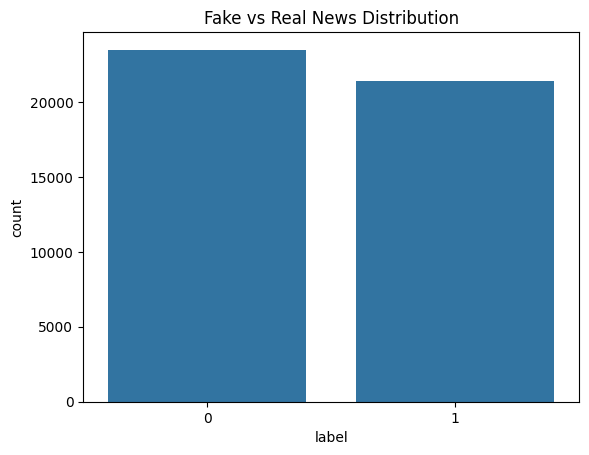

In [ ]:
sns.countplot(x="label", data=df)
plt.title("Fake vs Real News Distribution")
plt.show()

In [ ]:
#FINDING MISSING VALUES
print (df.isnull().sum())

title      0
text       0
subject    0
date       0
label      0
dtype: int64


In [ ]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/noorainbano/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
print(stopwords.words("english"))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [ ]:
#stemming of text
port_stem=PorterStemmer()
stop_words = set(stopwords.words("english"))   # run once

def stemming(content):
    content = re.sub("[^a-zA-Z]", " ", content)
    content = content.lower().split()
    content = [port_stem.stem(word) for word in content if word not in stop_words]
    return " ".join(content)


In [ ]:
#APPLYING THE STEM TO OUR TEXT DATA OF NEWS
df["text"]=df["text"].apply(stemming)

In [ ]:
#SPLITTING DATA INTO TRAINING AND TEST DATA
X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#CONVERTING TEXT TO NUMERIC DATA
vectorizer = TfidfVectorizer(max_features=3000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [ ]:
#TRAINING OUR MODEL,AND TESTING
model = LogisticRegression()
model.fit(X_train_vec, y_train)
y_pred = model.predict(X_test_vec)

In [ ]:
#ACCURACY EVALUATION
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9883073496659243

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      4678
           1       0.99      0.99      0.99      4302

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



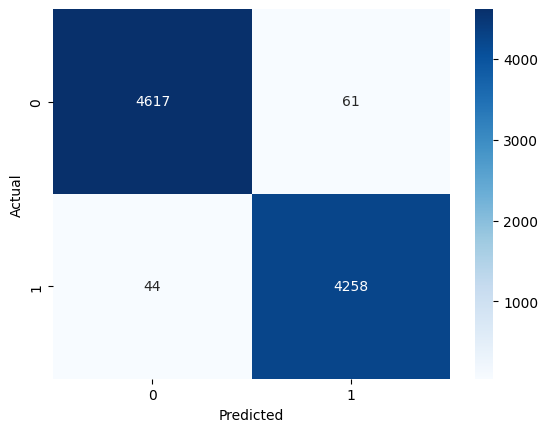

In [ ]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM (Linear)": LinearSVC()
}

for name, model in models.items():
    print("="*50)
    print(f"Training: {name}")
    
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    
    acc = accuracy_score(y_test, y_pred)
    
    print(f"\n{name} Accuracy: {acc * 100:.2f}%")
    print("Classification Report:\n")
    print(classification_report(y_test, y_pred, target_names=["FAKE", "REAL"]))

Training: Logistic Regression

Logistic Regression Accuracy: 98.83%
Classification Report:

              precision    recall  f1-score   support

        FAKE       0.99      0.99      0.99      4678
        REAL       0.99      0.99      0.99      4302

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980

Training: Naive Bayes

Naive Bayes Accuracy: 92.71%
Classification Report:

              precision    recall  f1-score   support

        FAKE       0.92      0.94      0.93      4678
        REAL       0.93      0.92      0.92      4302

    accuracy                           0.93      8980
   macro avg       0.93      0.93      0.93      8980
weighted avg       0.93      0.93      0.93      8980

Training: Random Forest

Random Forest Accuracy: 99.87%
Classification Report:

              precision    recall  f1-score   support

        FAKE       1.00      1.00      1.00

In [ ]:
#RESULT TABLE
results = []

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    acc = accuracy_score(y_test, y_pred)
    
    results.append([name, acc])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
print(results_df)

                 Model  Accuracy
0  Logistic Regression  0.988307
1          Naive Bayes  0.927060
2        Random Forest  0.997996
3         SVM (Linear)  0.995212


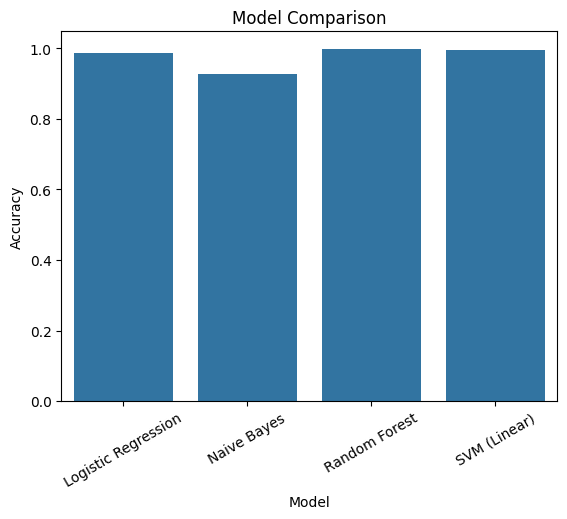

In [ ]:
#PLOT COMPARISON
sns.barplot(x="Model", y="Accuracy", data=results_df)
plt.xticks(rotation=30)
plt.title("Model Comparison")
plt.show()

In [ ]:
import warnings
warnings.filterwarnings("ignore")
pac = PassiveAggressiveClassifier(max_iter=1000)

scores = cross_val_score(pac, X_train_vec, y_train, cv=5)

print("Cross-validation scores:", scores)
print("Average Accuracy:", scores.mean())

Cross-validation scores: [0.99136971 0.99317929 0.99109131 0.99122929 0.9896979 ]
Average Accuracy: 0.9913135002001446


In [ ]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))